# Part 1 - Task 3: Data Exploration

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv('../data/processed/news_sample_cleaned.csv', low_memory=False)

print(f"Shape: {df.shape}")
print("\nColumns and dtypes:")
print(df.dtypes)

Shape: (238, 14)

Columns and dtypes:
id                    int64
domain                  str
type                  int64
url                     str
content                 str
scraped_at              str
title                   str
authors                 str
meta_keywords           str
meta_description        str
tags                    str
content_normalized      str
title_normalized        str
content_processed       str
dtype: object


We load the processed dataset produced by the preprocessing pipeline. The DataFrame contains one row per article, with columns for the raw and processed text, metadata, and a binary label (0 = reliable, 1 = fake).

## Observation 1: label Distribution
We examine the balance between reliable (0) and fake (1) articles in the dataset.

Label distribution:
  fake: 212 (89.1%
  reliable: 26 (10.9%


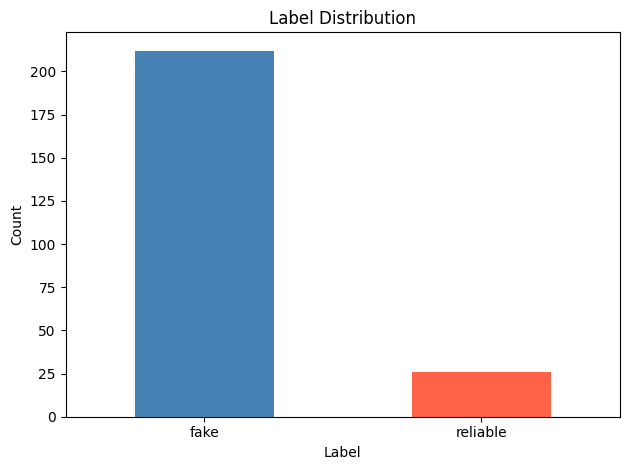

In [3]:
# Part 1.3 - Label distribution
label_counts = df['type'].value_counts()
label_names = {0: 'reliable', 1: 'fake'}

print("Label distribution:")
for label, count in label_counts.items():
    print(f"  {label_names[label]}: {count} ({count/len(df)*100:.1f}%")


label_counts.rename(index=label_names).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/labels_distribution.png')
plt.show()

## Observation 2: Article Length Distribution per Label
We compare the length of articles across reliable and fake labels.

reliable: mean=359, median=233, min=12, max=1707
fake: mean=402, median=286, min=9, max=3820


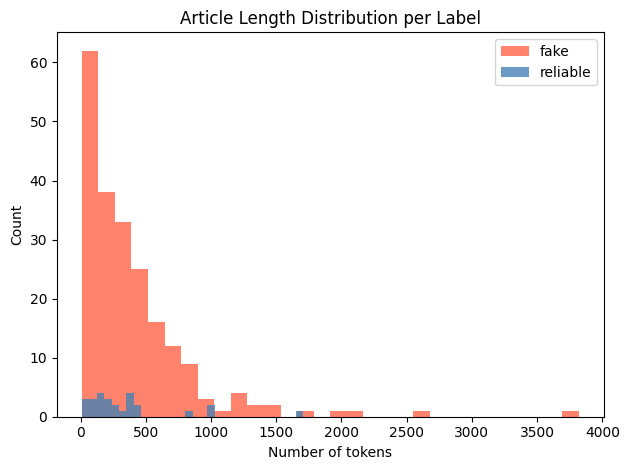

In [4]:
# Part 1.3 - Article length distribution per label
df['content_length'] = df['content_processed'].str.split().str.len()

for label, name in {0: 'reliable', 1: 'fake'}.items():
    subset = df[df['type'] == label]['content_length']
    print(f"{name}: mean={subset.mean():.0f}, median={subset.median():.0f}, min={subset.min():.0f}, max={subset.max()}")

fig, ax = plt.subplots()
for label, name, color in [(1, 'fake', 'tomato'), (0, 'reliable', 'steelblue')]:
    df[df['type'] == label]['content_length'].plot(kind='hist', bins=30, alpha=0.8, label=name, color=color, ax=ax)

ax.set_title('Article Length Distribution per Label')
ax.set_xlabel('Number of tokens')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/article_length_distribution.png')
plt.show()

## Observation 3: Domain Analysis
We examine which domains produce the most fake and reliable articles.


Top 10 reliable domains:
domain
washingtonexaminer.com    17
christianpost.com          3
alternet.org               2
city-journal.org           2
nationalreview.com         1
breitbart.com              1

Top 10 fake domains:
domain
beforeitsnews.com        155
canadafreepress.com       24
awarenessact.com           6
naturalnews.com            5
strategic-culture.org      4
awm.com                    2
undergroundhealth.com      2
vdare.com                  2
cnnnext.com                1
bipartisanreport.com       1


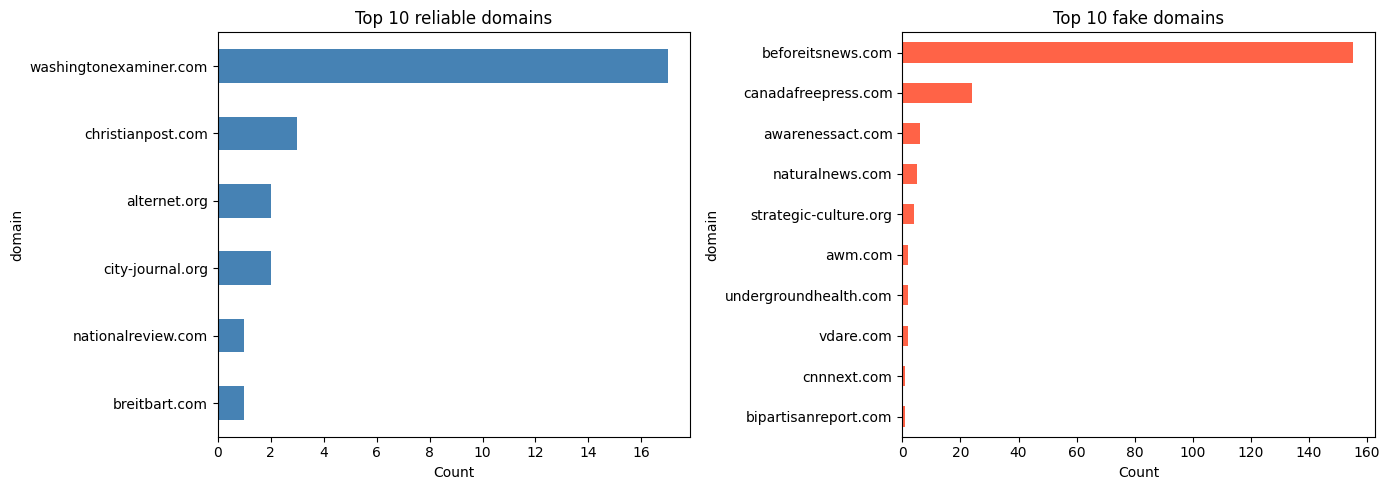

In [6]:
# Part 1.3 - Domain analysis per label
top_n = 10

for label, name in {0: 'reliable', 1: 'fake'}.items():
    top_domains = df[df['type'] == label]['domain'].value_counts().head(top_n)
    print(f"\nTop {top_n} {name} domains:")
    print(top_domains.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, (label, name, color) in zip(axes, [(0, 'reliable', 'steelblue'), (1, 'fake', 'tomato')]):
    top_domains = df[df['type'] == label]['domain'].value_counts().head(top_n)
    top_domains.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top {top_n} {name} domains')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/domain_analysis.png')
plt.show()

## Observation 4: Top-100 Words Before and After Stemming
We compare the most frequent words in the raw content versus the processed(stemmed) content.

In [8]:
# Part 1.3 - Top 100 words before and after stemming
words_raw = Counter(" ".join(df['content_normalized'].dropna()).split()).most_common(100)
words_stemmed = Counter(" ".join(df['content_processed'].dropna()).split()).most_common(100)

print("Top 20 words in raw content:")
for word, count in words_raw[:20]:
    print(f"  {word}: {count}")

print("\nTop 20 words in stemmed content:")
for word, count in words_stemmed[:20]:
    print(f"  {word}: {count}")  

Top 20 words in raw content:
  the: 9180
  of: 4813
  to: 4760
  and: 4568
  a: 3295
  in: 3018
  is: 2266
  that: 2143
  numtoken: 1957
  for: 1508
  it: 1311
  are: 1208
  with: 1138
  you: 1135
  this: 1133
  on: 1121
  as: 1059
  be: 907
  i: 864
  by: 804

Top 20 words in stemmed content:
  numtoken: 1988
  one: 471
  us: 436
  like: 405
  time: 398
  peopl: 379
  state: 355
  trump: 334
  year: 333
  use: 315
  would: 314
  market: 296
  also: 269
  new: 261
  blockchain: 260
  make: 254
  urltoken: 244
  go: 235
  thing: 233
  think: 230


We plot the top 30 most frequent words before and after stemming to visualize the effect of the preprocessing pipeline.

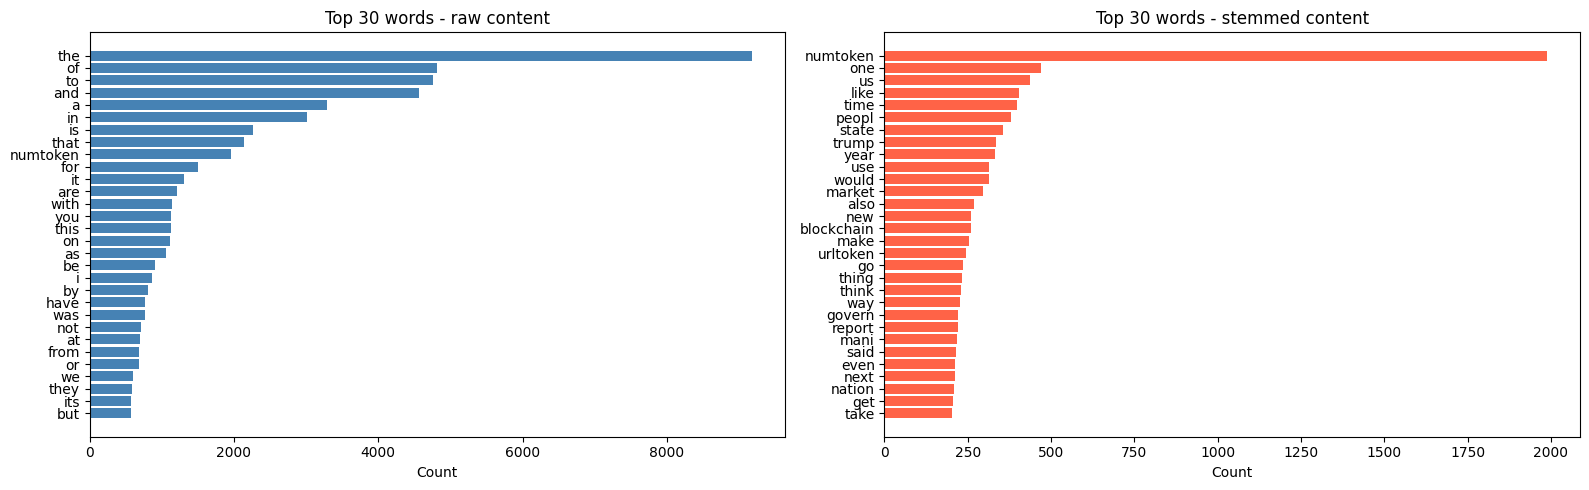

In [9]:
# Part 1.3 - Frequency plot of top 100 words before and after stemming
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_raw_labels, words_raw_counts = zip(*words_raw[:30])
words_stemmed_labels, words_stemmed_counts = zip(*words_stemmed[:30])

axes[0].barh(words_raw_labels[::-1], words_raw_counts[::-1], color='steelblue')
axes[0].set_title('Top 30 words - raw content')
axes[0].set_xlabel('Count')

axes[1].barh(words_stemmed_labels[::-1], words_stemmed_counts[::-1], color='tomato')
axes[1].set_title('Top 30 words - stemmed content')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../figures/top_words_frequency.png')
plt.show()

## Observation 5: Token Counts for URLs, Dates and Numbers
We count how often the preprocessing pipeline replaced URLs, dates and numbers in the content.

In [11]:
# Part 1.3 - Count special tokens per label
import re

patterns = {
    'URLs': r'https?://\S+|www\.\S+',
    'Dates': r'\b\d{1,4}[-/.]\d{1,2}[-/.]\d{1,4}\b',
    'Numbers': r'\b\d+\b',
}

for name, pattern in patterns.items():
    counts = df['content'].astype(str).apply(lambda x: len(re.findall(pattern, x)))
    print(f"{name}: total={counts.sum()}, mean per article={counts.mean():.2f}")

URLs: total=244, mean per article=1.03
Dates: total=36, mean per article=0.15
Numbers: total=2895, mean per article=12.16


In [12]:
for name, pattern in patterns.items():
    counts = df['content'].astype(str).apply(lambda x: len(re.findall(pattern, x)))
    df[f'{name}_count'] = counts
    for label, label_name in {0: 'reliable', 1: 'fake'}.items():
        subset = df[df['type'] == label][f'{name}_count']
        print(f"{name} - {label_name}: mean={subset.mean():.2f}")
    print()

URLs - reliable: mean=0.04
URLs - fake: mean=1.15

Dates - reliable: mean=0.00
Dates - fake: mean=0.17

Numbers - reliable: mean=7.31
Numbers - fake: mean=12.76

